✅ All libraries imported successfully!
📡 Stream generated: 150 events
🚨 True anomalies injected at events: [np.int64(30), np.int64(51), np.int64(56), np.int64(64), np.int64(72), np.int64(135), np.int64(146)]

📊 Stream Statistics:
   Mean     : 25.67°C
   Std Dev  : 4.26°C
   Min      : 19.76°C
   Max      : 47.63°C
✅ Isolation Forest model trained on historical data!
   contamination = 0.05 (expects ~5% anomalous events)
   The model is now ready to score live stream events.

 Event |  Temp (°C) | Rolling Mean |           Status
     1 |      25.99°C |       25.99°C | ✅ Normal
    11 |      24.07°C |       25.73°C | ✅ Normal
    21 |      27.93°C |       24.75°C | ✅ Normal
    31 |      39.73°C |       24.77°C | 🚨 ANOMALY DETECTED
    41 |      26.48°C |       25.19°C | ✅ Normal
    51 |      25.65°C |       24.53°C | ✅ Normal
    52 |      46.36°C |       25.41°C | 🚨 ANOMALY DETECTED
    57 |      44.96°C |       26.73°C | 🚨 ANOMALY DETECTED
    61 |      24.04°C |       27.01°C | ✅ N

/tmp/ipykernel_13109/2935271484.py:206: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_13109/2935271484.py:206: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_13109/2935271484.py:206: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_13109/2935271484.py:207: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/stream_analytics_demo_chart.png", dpi=150,
/tmp/ipykernel_13109/2935271484.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/stream_analytics_demo_chart.png", dpi=150,
/tmp/ipykernel_13109/2935271484.py:207: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefi

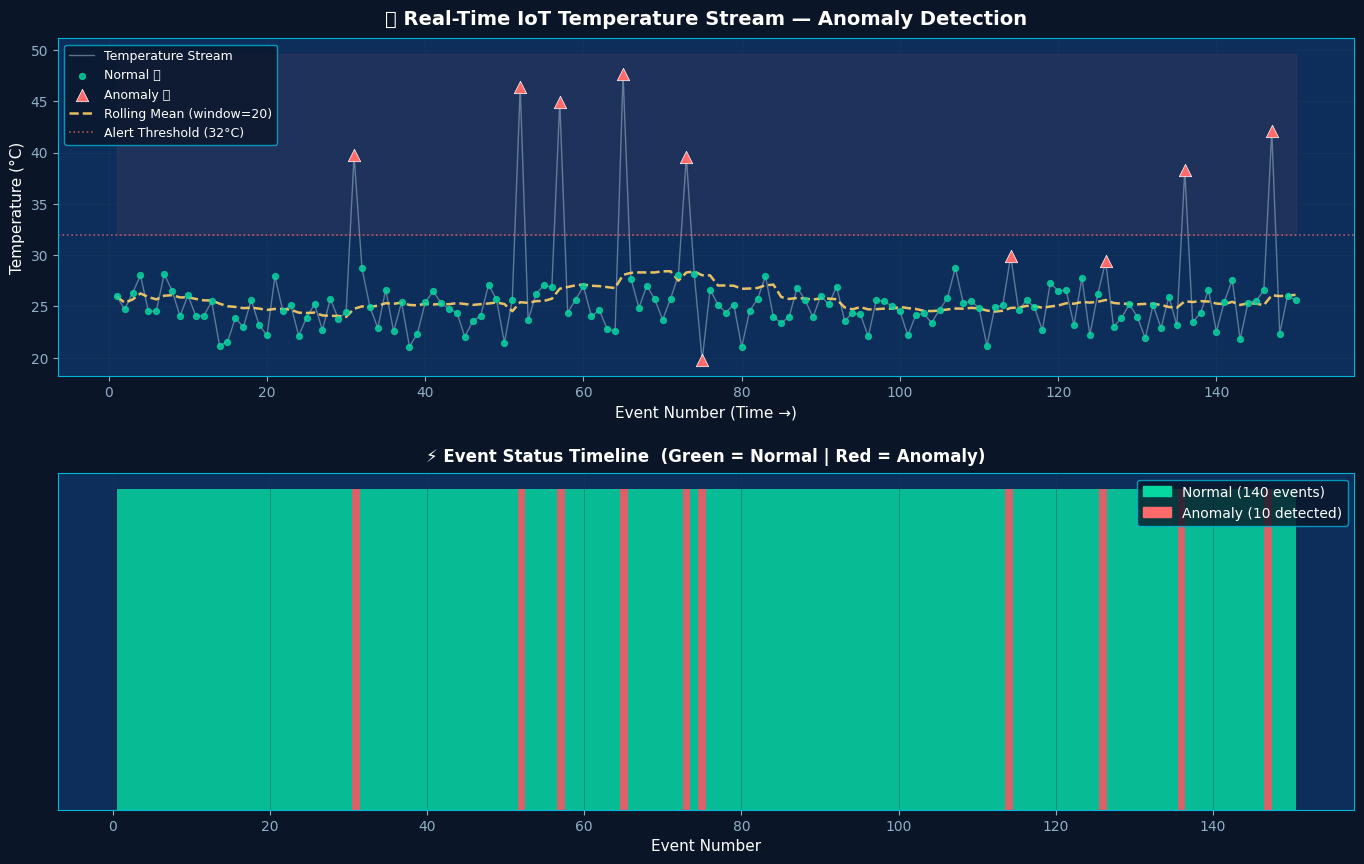


📊 Dashboard visualization complete!

📈 MODEL PERFORMANCE EVALUATION

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       143
     Anomaly       0.70      1.00      0.82         7

    accuracy                           0.98       150
   macro avg       0.85      0.99      0.91       150
weighted avg       0.99      0.98      0.98       150

🔢 Confusion Matrix:
   [True Neg  : 140]  [False Pos:   3]
   [False Neg :   0]  [True Pos :   7]

💡 KEY INSIGHT:
   Even a simple Isolation Forest model can detect most anomalies
   in a real-time stream — with no deep learning required!
   In production: retrain the model periodically to handle drift.

🎓 DEMO COMPLETE — Key Takeaways:
   1. Real-time streams process data EVENT-BY-EVENT, not in batches
   2. Sliding windows compute rolling statistics without storing all data
   3. Pre-trained ML models score each event instantly (<1ms per event)
   4. Anomalies are flagg

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from sklearn.ensemble import IsolationForest
import time
try:
    from IPython.display import clear_output
except ImportError:
    def clear_output(wait=False): pass

print("✅ All libraries imported successfully!")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Simulate a Real-Time Data Stream
# ─────────────────────────────────────────────────────────────────────────────
# In real systems, data arrives from IoT sensors, APIs, or Apache Kafka.
# Here, we simulate 150 temperature readings (in °C) arriving one-by-one.
# About 5% of readings will be artificially injected as anomalies (spikes).

def simulate_stream(n_events=150, anomaly_rate=0.05, seed=42):
    """
    Generates a synthetic IoT temperature stream.

    Parameters:
        n_events    : Total number of data events
        anomaly_rate: Fraction of events that are anomalies
        seed        : Random seed for reproducibility

    Returns:
        A pandas Series of temperature readings.
    """
    np.random.seed(seed)

    # Normal readings: mean 25°C, small variation (±2°C)
    stream = np.random.normal(loc=25.0, scale=2.0, size=n_events)

    # Inject anomalies: sudden spikes between 38°C and 48°C
    n_anomalies = int(n_events * anomaly_rate)
    anomaly_indices = np.random.choice(n_events, size=n_anomalies, replace=False)
    stream[anomaly_indices] = np.random.uniform(38, 48, size=n_anomalies)

    return pd.Series(stream), set(anomaly_indices)

# Generate the stream
stream_data, true_anomaly_idx = simulate_stream(n_events=150)

print(f"📡 Stream generated: {len(stream_data)} events")
print(f"🚨 True anomalies injected at events: {sorted(true_anomaly_idx)}")
print(f"\n📊 Stream Statistics:")
print(f"   Mean     : {stream_data.mean():.2f}°C")
print(f"   Std Dev  : {stream_data.std():.2f}°C")
print(f"   Min      : {stream_data.min():.2f}°C")
print(f"   Max      : {stream_data.max():.2f}°C")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Pre-Train the Anomaly Detection Model
# ─────────────────────────────────────────────────────────────────────────────
# In real streaming systems, a model is trained OFFLINE on historical data,
# then deployed to score incoming events in real time.
# We use Isolation Forest — a tree-based algorithm that isolates outliers.
# No complex math needed: it just asks "how easy is it to isolate this point?"

# Use the first 30 events as "historical normal" training data
training_data = np.random.normal(loc=25.0, scale=2.0, size=300).reshape(-1, 1)

model = IsolationForest(
    contamination=0.05,   # Expect ~5% anomalies
    n_estimators=100,     # Number of isolation trees
    random_state=42
)
model.fit(training_data)

print("✅ Isolation Forest model trained on historical data!")
print("   contamination = 0.05 (expects ~5% anomalous events)")
print("   The model is now ready to score live stream events.")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Process the Stream — Sliding Window + Detection
# ─────────────────────────────────────────────────────────────────────────────
# We process each event one at a time (simulating real-time arrival).
# A sliding window of the last 20 events tracks the rolling mean.
# The Isolation Forest labels each event: +1 = Normal, -1 = Anomaly.

WINDOW_SIZE = 20   # Rolling window for statistics

# Storage for visualization
all_values  = []
all_labels  = []   # 'normal' or 'anomaly'
rolling_means = []
timestamps  = []

window = deque(maxlen=WINDOW_SIZE)  # Sliding window buffer

print("\n" + "="*65)
print(f"{'Event':>6} | {'Temp (°C)':>10} | {'Rolling Mean':>12} | {'Status':>16}")
print("="*65)

for i, value in enumerate(stream_data):

    # 1. Add to sliding window
    window.append(value)

    # 2. Compute rolling mean (summary statistic)
    roll_mean = np.mean(window)

    # 3. Score the event using the pre-trained model
    label_code = model.predict([[value]])[0]   # +1 = normal, -1 = anomaly
    label = "anomaly" if label_code == -1 else "normal"

    # 4. Store results
    all_values.append(value)
    all_labels.append(label)
    rolling_means.append(roll_mean)
    timestamps.append(i + 1)

    # 5. Display output (show every 10th event + all anomalies)
    status_icon = "🚨 ANOMALY DETECTED" if label == "anomaly" else "✅ Normal"
    if label == "anomaly" or i % 10 == 0:
        print(f"{i+1:>6} | {value:>10.2f}°C | {roll_mean:>11.2f}°C | {status_icon}")

print("="*65)

# Summary
n_detected = all_labels.count("anomaly")
n_normal   = all_labels.count("normal")
print(f"\n📊 Stream Processing Complete!")
print(f"   Total events processed : {len(all_values)}")
print(f"   Normal events          : {n_normal}")
print(f"   Anomalies detected     : {n_detected}")
print(f"   Detection rate         : {n_detected/len(true_anomaly_idx)*100:.0f}% of injected anomalies caught")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Visualization — Real-Time Stream Dashboard
# ─────────────────────────────────────────────────────────────────────────────
# Now we create a professional visualization simulating a live dashboard.
# In production, tools like Grafana or Apache Superset would display this.

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor("#0A1628")

# ── Plot 1: Stream with Anomaly Markers ──────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0D2E5A")
ax1.tick_params(colors="white")
for spine in ax1.spines.values():
    spine.set_edgecolor("#00B4D8")

# Plot all values as a continuous stream line
ax1.plot(timestamps, all_values, color="#90AFC5", linewidth=1.0,
         alpha=0.6, label="Temperature Stream")

# Plot normal points
normal_t  = [timestamps[i] for i in range(len(all_labels)) if all_labels[i] == "normal"]
normal_v  = [all_values[i]  for i in range(len(all_labels)) if all_labels[i] == "normal"]
ax1.scatter(normal_t, normal_v, color="#06D6A0", s=18, zorder=3,
            label="Normal ✅", alpha=0.8)

# Plot anomaly points (larger, red)
anomaly_t = [timestamps[i] for i in range(len(all_labels)) if all_labels[i] == "anomaly"]
anomaly_v = [all_values[i]  for i in range(len(all_labels)) if all_labels[i] == "anomaly"]
ax1.scatter(anomaly_t, anomaly_v, color="#FF6B6B", s=80, marker="^",
            zorder=5, label="Anomaly 🚨", edgecolors="white", linewidths=0.5)

# Rolling mean
ax1.plot(timestamps, rolling_means, color="#FFD166", linewidth=1.8,
         linestyle="--", label=f"Rolling Mean (window={WINDOW_SIZE})", alpha=0.9)

# Threshold zone
threshold = 32
ax1.axhline(y=threshold, color="#FF6B6B", linewidth=1.2, linestyle=":",
            alpha=0.7, label=f"Alert Threshold ({threshold}°C)")
ax1.fill_between(timestamps, threshold, max(all_values) + 2,
                 alpha=0.08, color="#FF6B6B")

ax1.set_title("📡 Real-Time IoT Temperature Stream — Anomaly Detection",
              color="white", fontsize=14, fontweight="bold", pad=10)
ax1.set_ylabel("Temperature (°C)", color="white", fontsize=11)
ax1.set_xlabel("Event Number (Time →)", color="white", fontsize=11)
ax1.legend(facecolor="#0A1628", edgecolor="#00B4D8", labelcolor="white",
           fontsize=9, loc="upper left")
ax1.tick_params(axis="both", colors="#90AFC5")
ax1.grid(True, color="#1C3A5A", linewidth=0.5, alpha=0.6)

# ── Plot 2: Anomaly Timeline (Status Bar) ────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D2E5A")

colors = ["#FF6B6B" if l == "anomaly" else "#06D6A0" for l in all_labels]
ax2.bar(timestamps, [1] * len(timestamps), color=colors, width=1.0, alpha=0.85)
ax2.set_title("⚡ Event Status Timeline  (Green = Normal | Red = Anomaly)",
              color="white", fontsize=12, fontweight="bold", pad=8)
ax2.set_xlabel("Event Number", color="white", fontsize=11)
ax2.set_yticks([])
ax2.tick_params(axis="x", colors="#90AFC5")
for spine in ax2.spines.values():
    spine.set_edgecolor("#00B4D8")
ax2.grid(axis="x", color="#1C3A5A", linewidth=0.5, alpha=0.5)

normal_patch  = mpatches.Patch(color="#06D6A0", label=f"Normal ({n_normal} events)")
anomaly_patch = mpatches.Patch(color="#FF6B6B", label=f"Anomaly ({n_detected} detected)")
ax2.legend(handles=[normal_patch, anomaly_patch], facecolor="#0A1628",
           edgecolor="#00B4D8", labelcolor="white", fontsize=10)

plt.tight_layout(pad=2.0)
plt.savefig("/content/stream_analytics_demo_chart.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("\n📊 Dashboard visualization complete!")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Performance Evaluation
# ─────────────────────────────────────────────────────────────────────────────
# Let's evaluate how well our model detected the injected anomalies.

from sklearn.metrics import classification_report, confusion_matrix

# Create true labels array (1 = anomaly, 0 = normal)
true_labels = [1 if i in true_anomaly_idx else 0 for i in range(len(stream_data))]
pred_labels = [1 if l == "anomaly" else 0 for l in all_labels]

print("\n" + "="*55)
print("📈 MODEL PERFORMANCE EVALUATION")
print("="*55)
print("\n📋 Classification Report:")
print(classification_report(true_labels, pred_labels,
                             target_names=["Normal", "Anomaly"],
                             zero_division=0))

cm = confusion_matrix(true_labels, pred_labels)
print("🔢 Confusion Matrix:")
print(f"   [True Neg  : {cm[0][0]:3d}]  [False Pos: {cm[0][1]:3d}]")
print(f"   [False Neg : {cm[1][0]:3d}]  [True Pos : {cm[1][1]:3d}]")

print("\n💡 KEY INSIGHT:")
print("   Even a simple Isolation Forest model can detect most anomalies")
print("   in a real-time stream — with no deep learning required!")
print("   In production: retrain the model periodically to handle drift.")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Bonus — Simulate Animated Event-by-Event Processing
# ─────────────────────────────────────────────────────────────────────────────
# This section simulates actual real-time processing — the chart updates
# as each new event arrives, just like a production streaming dashboard.
# NOTE: Run this LAST. It takes ~30 seconds.

def run_live_simulation(stream, model, delay=0.15, max_events=60):
    """
    Simulates real-time stream processing with live chart updates.
    Shows events arriving one-by-one and the dashboard updating live.
    """
    window = deque(maxlen=20)
    live_vals = []
    live_labels = []
    live_means = []

    print("🔴 LIVE SIMULATION STARTING — watch the chart update in real-time!")
    print(f"   Processing {max_events} events with {delay}s delay between each...\n")

    for i, val in enumerate(stream[:max_events]):
        window.append(val)
        roll_mean = np.mean(window)
        label = "anomaly" if model.predict([[val]])[0] == -1 else "normal"

        live_vals.append(val)
        live_labels.append(label)
        live_means.append(roll_mean)

        # Update chart
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(13, 4))
        fig.patch.set_facecolor("#0A1628")
        ax.set_facecolor("#0D2E5A")

        t = list(range(1, len(live_vals) + 1))
        colors = ["#FF6B6B" if l == "anomaly" else "#06D6A0" for l in live_labels]

        ax.plot(t, live_vals, color="#90AFC5", linewidth=1.0, alpha=0.5)
        ax.scatter(t, live_vals, c=colors, s=25, zorder=3, alpha=0.9)
        ax.plot(t, live_means, color="#FFD166", linewidth=2.0, linestyle="--", alpha=0.9)
        ax.axhline(y=32, color="#FF6B6B", linewidth=1.0, linestyle=":", alpha=0.7)

        status_text = f"🚨 ANOMALY at Event {i+1}!" if label == "anomaly" else f"✅ Event {i+1}: Normal"
        ax.set_title(f"⚡ LIVE STREAM  |  {status_text}  |  Temp: {val:.1f}°C",
                     color="white", fontsize=12, fontweight="bold")
        ax.set_xlabel("Event #", color="white"); ax.set_ylabel("°C", color="white")
        ax.tick_params(colors="#90AFC5"); ax.grid(color="#1C3A5A", alpha=0.5)
        for sp in ax.spines.values(): sp.set_edgecolor("#00B4D8")
        ax.set_xlim(0, max_events + 1)
        ax.set_ylim(stream[:max_events].min() - 3, stream[:max_events].max() + 3)

        plt.tight_layout()
        plt.show()
        time.sleep(delay)

    print(f"\n✅ Live simulation complete! Processed {max_events} events.")

# UNCOMMENT the line below to run the live animation:
# run_live_simulation(stream_data, model, delay=0.15, max_events=60)

print("\n" + "="*65)
print("🎓 DEMO COMPLETE — Key Takeaways:")
print("   1. Real-time streams process data EVENT-BY-EVENT, not in batches")
print("   2. Sliding windows compute rolling statistics without storing all data")
print("   3. Pre-trained ML models score each event instantly (<1ms per event)")
print("   4. Anomalies are flagged immediately — enabling instant alerts")
print("   5. This pattern scales to millions of events/second in production")
print("="*65)